In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

df = pd.read_csv("wine.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (178, 14)

First 5 Rows:
   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to

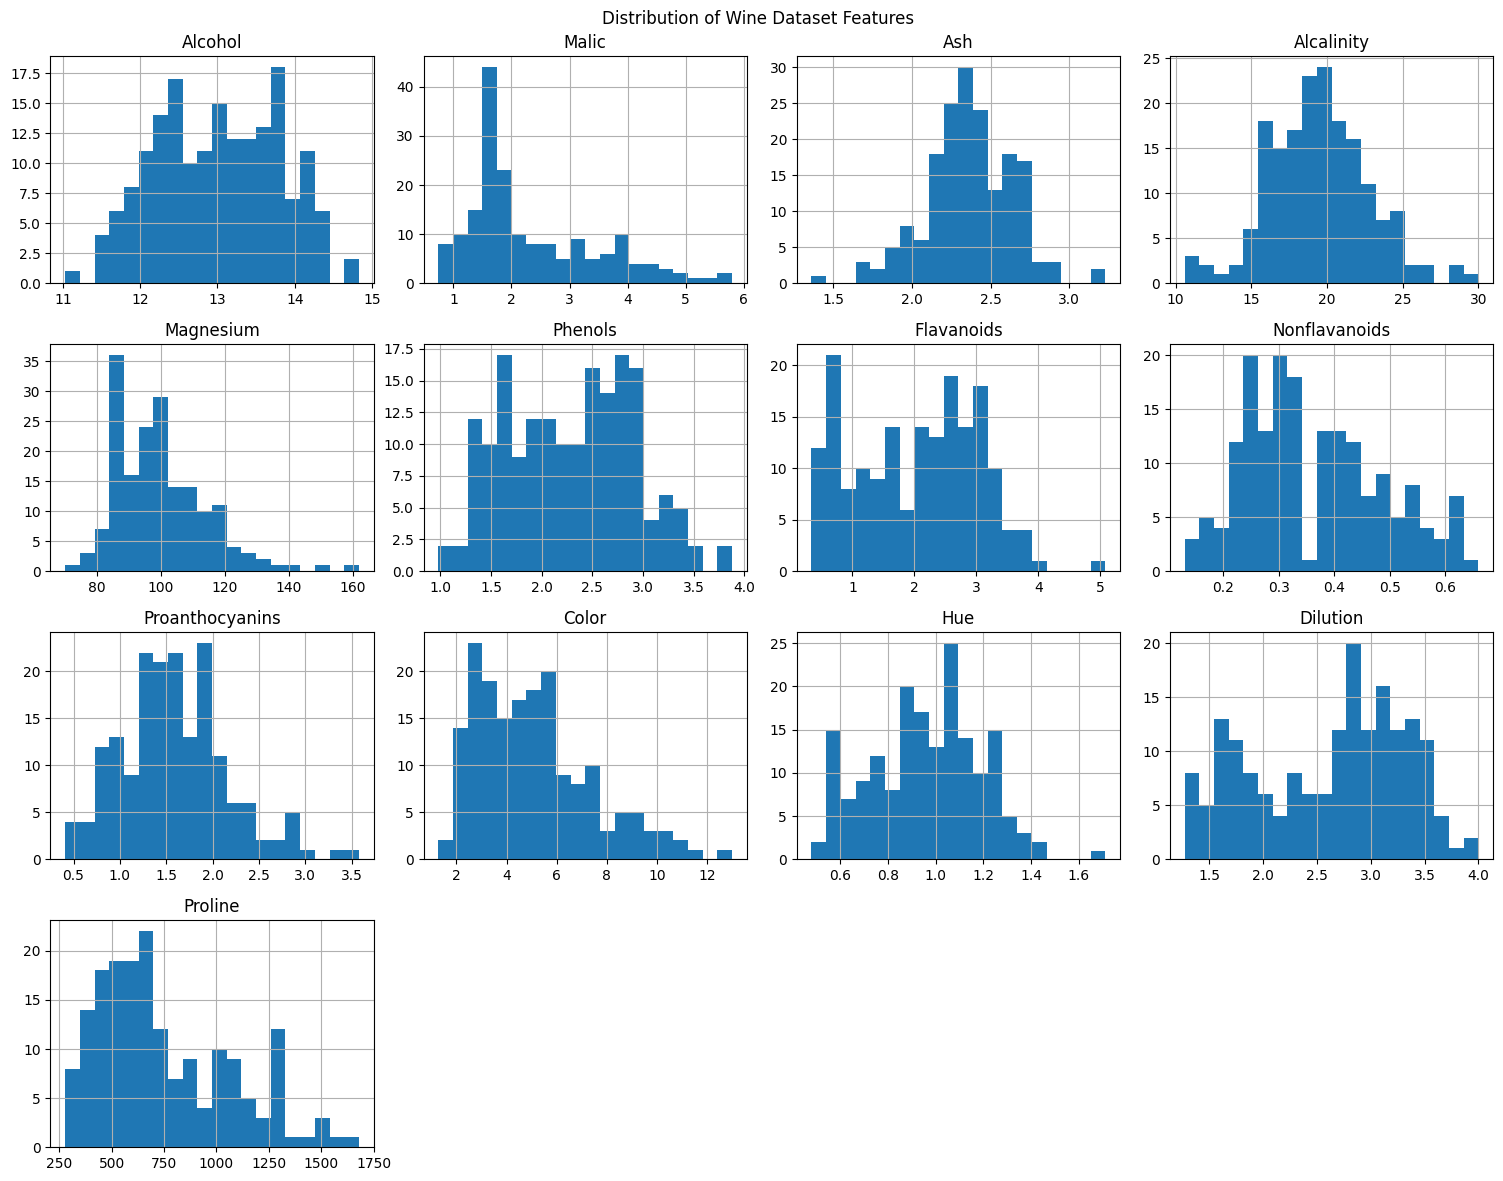

In [44]:
features = df.drop(
    columns=['Type']
)

features.hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Wine Dataset Features"
)

plt.tight_layout()
plt.show()

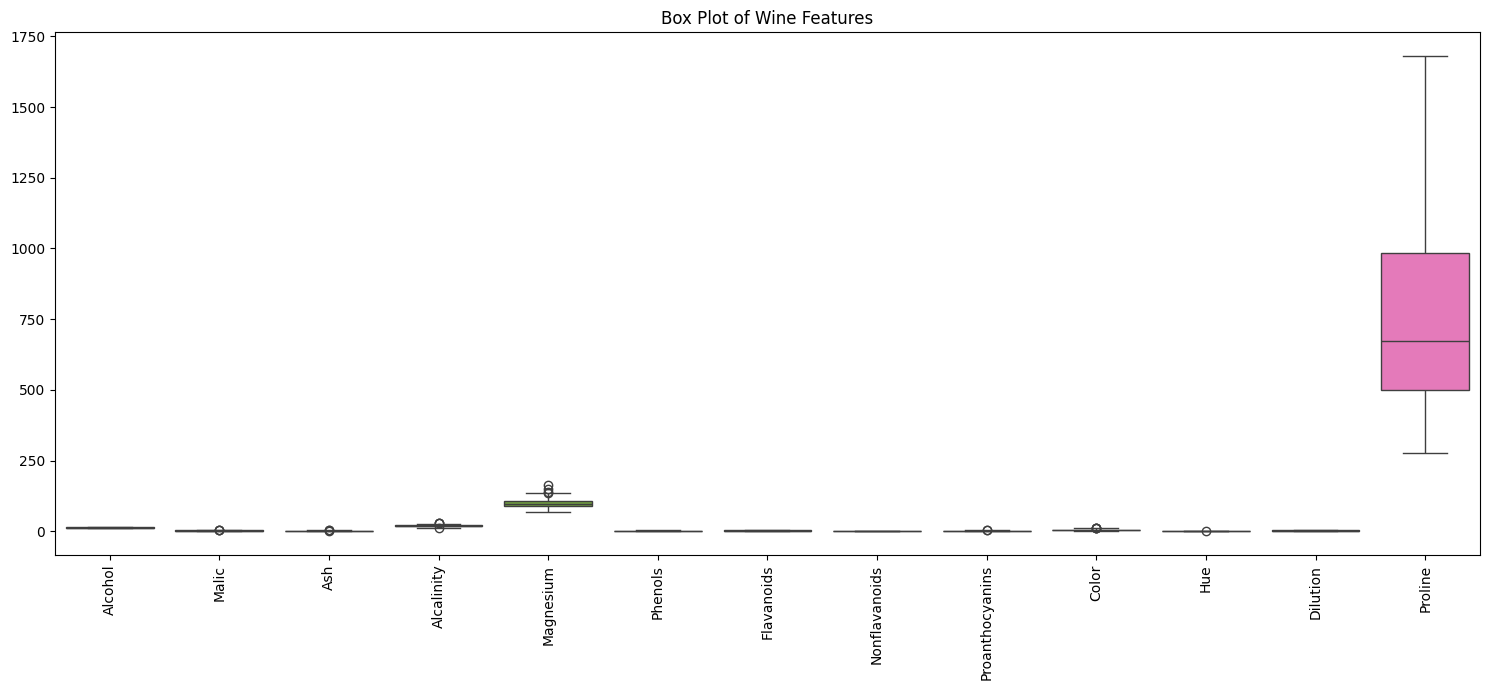

In [45]:
#Boxplot
plt.figure(
    figsize=(15, 7)
)

sns.boxplot(
    data=features
)

plt.title(
    "Box Plot of Wine Features"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()
plt.show()

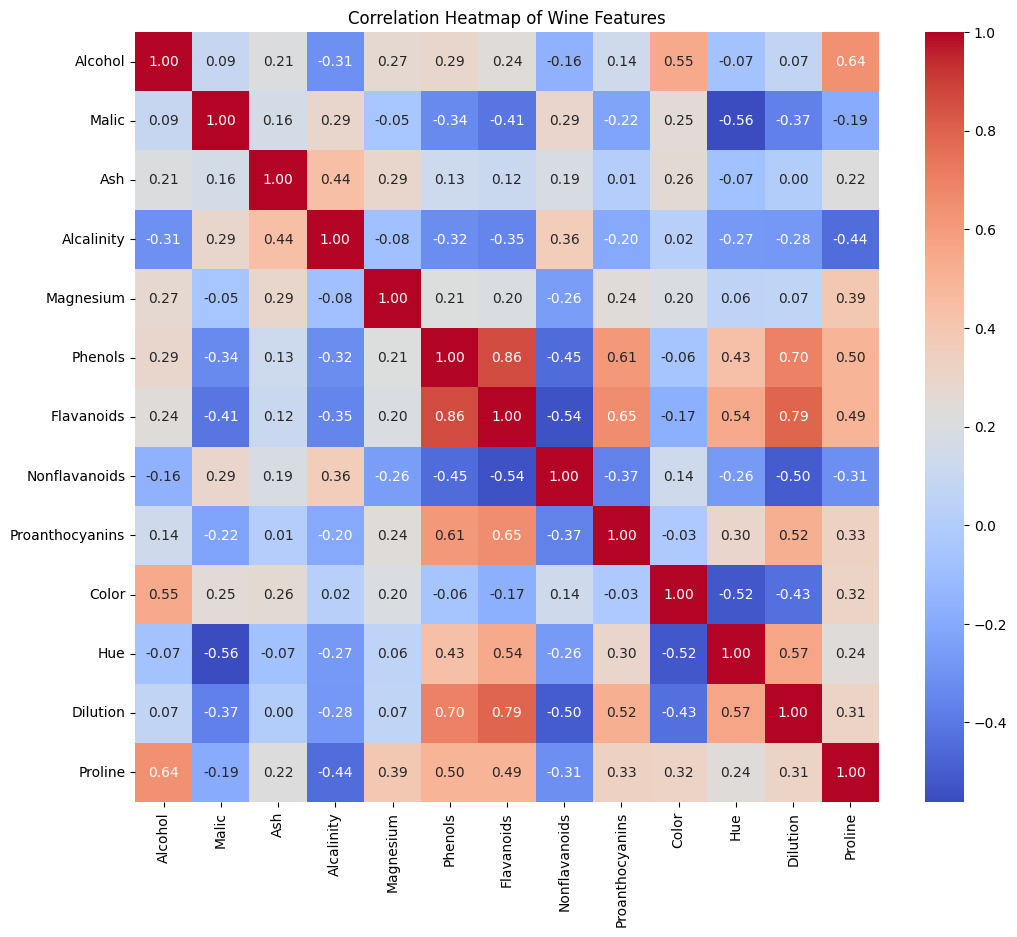

In [46]:
#task1
plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    features.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title(
    "Correlation Heatmap of Wine Features"
)

plt.show()

In [48]:
#task2
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    features
)

print(
    "Original Shape:",
    features.shape
)

print(
    "Scaled Shape:",
    X_scaled.shape
)

pca_full = PCA()

X_pca_full = pca_full.fit_transform(
    X_scaled
)

explained_variance = (
    pca_full.explained_variance_ratio_
)

cumulative_variance = np.cumsum(
    explained_variance
)

print("Explained Variance Ratio:")
print(explained_variance)

print("\nCumulative Explained Variance:")
print(cumulative_variance)

Original Shape: (178, 13)
Scaled Shape: (178, 13)
Explained Variance Ratio:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]

Cumulative Explained Variance:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


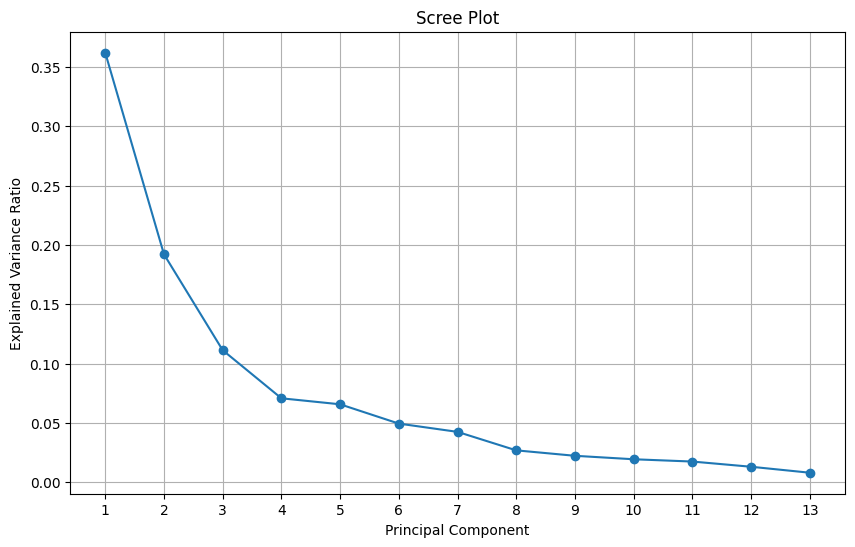

In [49]:
#scree plot
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o'
)

plt.xlabel(
    "Principal Component"
)

plt.ylabel(
    "Explained Variance Ratio"
)

plt.title(
    "Scree Plot"
)

plt.xticks(
    range(1, len(explained_variance) + 1)
)

plt.grid()

plt.show()

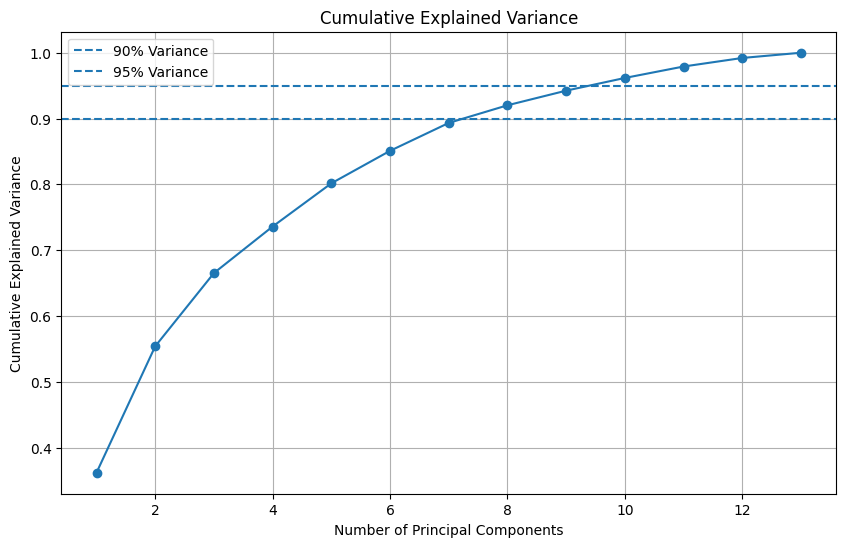

In [50]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.90,
    linestyle='--',
    label='90% Variance'
)

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% Variance'
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "Cumulative Explained Variance"
)

plt.legend()

plt.grid()

plt.show()

In [51]:
n_components_90 = np.argmax(
    cumulative_variance >= 0.90
) + 1

n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    "Components required for 90% variance:",
    n_components_90
)

print(
    "Components required for 95% variance:",
    n_components_95
)

Components required for 90% variance: 8
Components required for 95% variance: 10


In [52]:
pca = PCA(
    n_components=n_components_90
)

X_pca = pca.fit_transform(
    X_scaled
)

print(
    "Original Feature Shape:",
    X_scaled.shape
)

print(
    "PCA Feature Shape:",
    X_pca.shape
)

print(
    "\nExplained Variance:",
    pca.explained_variance_ratio_
)

print(
    "\nTotal Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

Original Feature Shape: (178, 13)
PCA Feature Shape: (178, 8)

Explained Variance: [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749]

Total Explained Variance: 0.9201754434577263


In [53]:
#data frame
pca_columns = [
    f'PC{i}'
    for i in range(1, n_components_90 + 1)
]

pca_df = pd.DataFrame(
    X_pca,
    columns=pca_columns
)

print(pca_df.head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  3.316751  1.443463 -0.165739 -0.215631  0.693043  0.223880  0.596427   
1  2.209465 -0.333393 -2.026457 -0.291358 -0.257655  0.927120  0.053776   
2  2.516740  1.031151  0.982819  0.724902 -0.251033 -0.549276  0.424205   
3  3.757066  2.756372 -0.176192  0.567983 -0.311842 -0.114431 -0.383337   
4  1.008908  0.869831  2.026688 -0.409766  0.298458  0.406520  0.444074   

        PC8  
0 -0.065139  
1 -1.024416  
2  0.344216  
3 -0.643593  
4 -0.416700  


In [54]:
#task3
kmeans_original = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_original = kmeans_original.fit_predict(
    X_scaled
)

print(
    "Cluster Distribution:"
)

print(
    pd.Series(
        clusters_original
    ).value_counts().sort_index()
)

Cluster Distribution:
0    65
1    51
2    62
Name: count, dtype: int64


In [55]:
silhouette_original = silhouette_score(
    X_scaled,
    clusters_original
)

db_original = davies_bouldin_score(
    X_scaled,
    clusters_original
)

print(
    "Original Data Silhouette Score:",
    silhouette_original
)

print(
    "Original Data Davies-Bouldin Index:",
    db_original
)

Original Data Silhouette Score: 0.2848589191898987
Original Data Davies-Bouldin Index: 1.3891879777181648


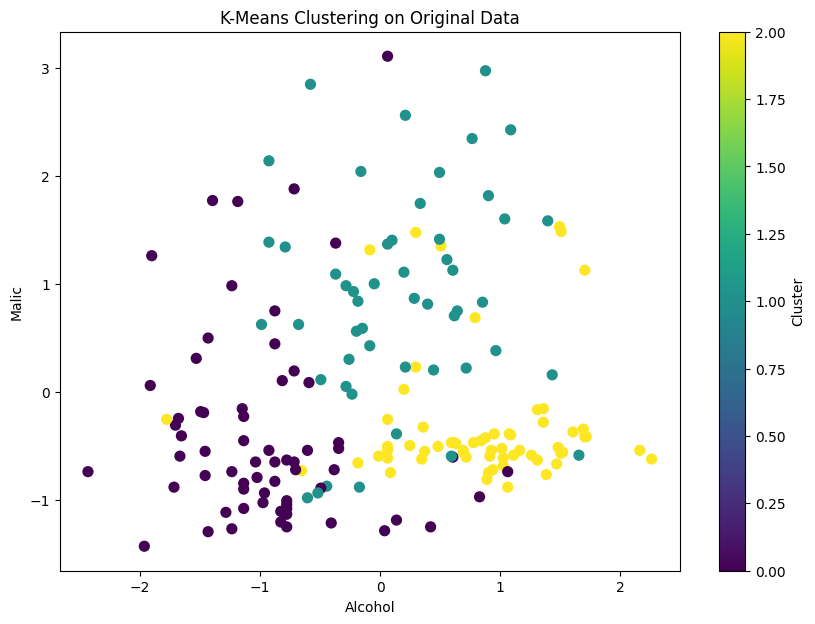

In [56]:
plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters_original,
    cmap='viridis',
    s=50
)

plt.xlabel(
    features.columns[0]
)

plt.ylabel(
    features.columns[1]
)

plt.title(
    "K-Means Clustering on Original Data"
)

plt.colorbar(
    label='Cluster'
)

plt.show()

In [58]:
#task4
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_pca = kmeans_pca.fit_predict(
    X_pca
)

print(
    "PCA Cluster Distribution:"
)

print(
    pd.Series(
        clusters_pca
    ).value_counts().sort_index()
)

silhouette_pca = silhouette_score(
    X_pca,
    clusters_pca
)

db_pca = davies_bouldin_score(
    X_pca,
    clusters_pca
)

print(
    "PCA Data Silhouette Score:",
    silhouette_pca
)

print(
    "PCA Data Davies-Bouldin Index:",
    db_pca
)

PCA Cluster Distribution:
0    65
1    51
2    62
Name: count, dtype: int64
PCA Data Silhouette Score: 0.3149696954705561
PCA Data Davies-Bouldin Index: 1.2668818314972183


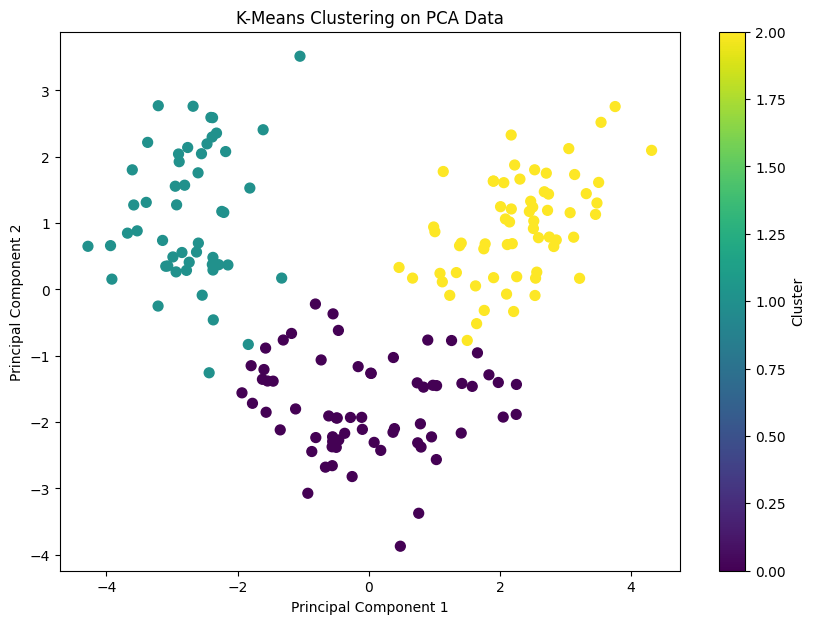

In [59]:
#PCA visualization
plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_pca,
    cmap='viridis',
    s=50
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "K-Means Clustering on PCA Data"
)

plt.colorbar(
    label='Cluster'
)

plt.show()

In [60]:
comparison = pd.DataFrame({
    'Dataset': [
        'Original Data',
        'PCA Data'
    ],

    'Silhouette Score': [
        silhouette_original,
        silhouette_pca
    ],

    'Davies-Bouldin Index': [
        db_original,
        db_pca
    ]
})

print(comparison)

         Dataset  Silhouette Score  Davies-Bouldin Index
0  Original Data          0.284859              1.389188
1       PCA Data          0.314970              1.266882


# Task 5: Comparison and Analysis

The clustering results from the original standardized dataset and the
PCA-transformed dataset are compared using Silhouette Score and
Davies-Bouldin Index.

### Interpretation

The Silhouette Score measures how well each observation fits within its
assigned cluster compared with other clusters. A higher score indicates
better clustering.

The Davies-Bouldin Index measures the similarity between clusters. A lower
value indicates better separation and compactness.

PCA reduces the number of dimensions while retaining the majority of the
important information in the dataset. This can make clustering computationally
simpler and can reduce the effect of redundant or highly correlated features.

However, PCA may also remove some information that is useful for clustering.
Therefore, PCA does not always produce better clustering performance than
using the original standardized features.

### Trade-offs

#### Advantages of PCA before clustering

- Reduces dimensionality.
- Removes some redundant information.
- Can reduce computational complexity.
- Makes high-dimensional data easier to visualize.
- Can improve clustering when noisy or highly correlated features are present.

#### Disadvantages of PCA

- Principal components are combinations of the original variables and can be
  difficult to interpret.
- Some information may be lost.
- Clustering performance may decrease if discarded components contain useful
  information.

#### Clustering directly on original data

Using the original standardized data preserves all available features and
maintains better feature interpretability. However, high-dimensional data can
increase computational complexity and may contain redundant information.


# Task 6: Conclusion and Insights

PCA and K-Means clustering were applied to the Wine dataset.

The dataset was first explored using statistical summaries, histograms,
box plots, and correlation analysis. The features were standardized because
PCA and K-Means are sensitive to differences in feature scale.

PCA was then applied to reduce the dimensionality of the dataset. A scree
plot and cumulative explained variance were used to determine an appropriate
number of principal components.

K-Means clustering was performed both on the original standardized data and
on the PCA-transformed data. Silhouette Score and Davies-Bouldin Index were
used to compare clustering quality.

The results demonstrate that dimensionality reduction can simplify
high-dimensional datasets while retaining much of their important
information. However, the best approach depends on whether PCA improves the
clustering metrics and whether interpretability of the original features is
important.

### Recommendations

PCA is recommended when:

- The dataset has many features.
- Features are highly correlated.
- Dimensionality needs to be reduced.
- Visualization of high-dimensional data is required.
- Computational efficiency is important.

Clustering directly on the original standardized data is recommended when:

- The number of features is relatively small.
- Original feature interpretability is important.
- Removing dimensions may result in useful information being lost.